In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sohaibdevv/ai-and-student-life-2026-the-new-normal/AI_Impact_Student_Life_2026.csv


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/kaggle/input/datasets/sohaibdevv/ai-and-student-life-2026-the-new-normal/AI_Impact_Student_Life_2026.csv')
df.head(10)

,Student_ID,Age,Major,Primary_AI_Tool,Task_Frequency_Daily,Main_Usage_Case,GPA_Baseline,GPA_Post_AI,Time_Saved_Hours_Weekly,AI_Ethics_Concern,Career_Confidence_Score
0,STU-6019,23,Software Engineering,Gemini Pro,1,Code Debugging,2.62,2.62,9,Medium,3
1,STU-6962,22,Modern History,GitHub Copilot,3,Essay Drafting,3.99,4.00,7,Medium,4
2,STU-2338,18,Data Science,Perplexity,2,Literature Review,2.57,2.57,15,High,7
3,STU-1380,19,Biology,Claude 3.5,5,Essay Drafting,2.67,2.87,12,Low,5
4,STU-1837,19,Biology,ChatGPT-4o,10,Code Debugging,3.65,3.85,5,High,9
5,STU-0052,19,Software Engineering,ChatGPT-4o,4,Essay Drafting,3.21,3.41,8,Medium,4
6,STU-4953,19,Business Administration,GitHub Copilot,1,Exam Prep,3.87,3.97,7,Low,1
7,STU-1723,20,Fine Arts,Perplexity,3,Exam Prep,3.18,3.08,2,Medium,9
8,STU-5100,20,Fine Arts,ChatGPT-4o,1,Literature Review,3.25,3.35,13,Medium,8
9,STU-7291,19,Fine Arts,GitHub Copilot,5,Exam Prep,3.43,3.33,10,Medium,3


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Student_ID               1500 non-null   object 
 1   Age                      1500 non-null   int64  
 2   Major                    1500 non-null   object 
 3   Primary_AI_Tool          1500 non-null   object 
 4   Task_Frequency_Daily     1500 non-null   int64  
 5   Main_Usage_Case          1500 non-null   object 
 6   GPA_Baseline             1500 non-null   float64
 7   GPA_Post_AI              1500 non-null   float64
 8   Time_Saved_Hours_Weekly  1500 non-null   int64  
 9   AI_Ethics_Concern        1500 non-null   object 
 10  Career_Confidence_Score  1500 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 129.0+ KB


In [5]:
feature = {
    "Student_ID": "A unique identifier for each student.",
    "Age": "Age of the student, ranging from 18 to 25 years.",
    "Major": "The student's field of study (e.g., Software Engineering, Business, Arts).",
    "Primary_AI_Tool": "The main AI platform the student uses for academic work.",
    "Task_Frequency_Daily": "Estimated number of times a student interacts with AI tools per day.",
    "Main_Usage_Case": "The primary way AI is utilized (e.g., Debugging, Research, Exam Prep).",
    "GPA_Baseline": "The student's Grade Point Average before integrating AI into their study routine.",
    "GPA_Post_AI": "The student's current Grade Point Average after adopting AI tools.",
    "Time_Saved_Hours_Weekly": "Estimated hours saved per week by using AI for manual or repetitive tasks.",
    "AI_Ethics_Concern": "Level of concern regarding academic integrity and original work (Low/Medium/High)."
}

In [6]:
df.describe().round(2)

,Age,Task_Frequency_Daily,GPA_Baseline,GPA_Post_AI,Time_Saved_Hours_Weekly,Career_Confidence_Score
count,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00
mean,21.49,5.41,3.26,3.34,8.51,5.42
std,2.30,2.91,0.43,0.44,4.07,2.84
min,18.00,1.00,2.50,2.40,2.00,1.00
25%,20.00,3.00,2.88,2.98,5.00,3.00
50%,21.00,5.00,3.26,3.36,9.00,5.00
75%,23.00,8.00,3.62,3.71,12.00,8.00
max,25.00,10.00,4.00,4.00,15.00,10.00


In [7]:
data_assessment = pd.DataFrame({
    "Column": df.columns,
    "Data Type": [df[col].dtype for col in df.columns],
    "Missing Values": [f"{df[col].isna().mean() * 100:.1f}%" for col in df.columns],
    "Unique Values": [df[col].nunique() for col in df.columns],
    "Example Value": [df[col].dropna().iloc[0] if df[col].notna().any() else None for col in df.columns]
})
data_assessment

,Column,Data Type,Missing Values,Unique Values,Example Value
0,Student_ID,object,0.0%,1500,STU-6019
1,Age,int64,0.0%,8,23
2,Major,object,0.0%,6,Software Engineering
3,Primary_AI_Tool,object,0.0%,5,Gemini Pro
4,Task_Frequency_Daily,int64,0.0%,10,1
5,Main_Usage_Case,object,0.0%,5,Code Debugging
6,GPA_Baseline,float64,0.0%,151,2.62
7,GPA_Post_AI,float64,0.0%,187,2.62
8,Time_Saved_Hours_Weekly,int64,0.0%,14,9
9,AI_Ethics_Concern,object,0.0%,3,Medium


In [8]:
#Hypothesis test
# Does the GPA improve after the use of AI?

#h0 - GPA does't improve, there's no meaningful difference.
#h1 - GPA does improve meaninfully with the usage of AI

In [9]:
'''
#Distributions

#Paired Distributions
Major vs Primary AI tool
Major vs Main Usage Case
Major vs Ethics Concern
Major vs GPA before and After

#Hypothesis Test
GPA before and After
GPA before and After per Major
GPA before and After per AI tool
'''

'\n#Distributions\n\n#Paired Distributions\nMajor vs Primary AI tool\nMajor vs Main Usage Case\nMajor vs Ethics Concern\nMajor vs GPA before and After\n\n#Hypothesis Test\nGPA before and After\nGPA before and After per Major\nGPA before and After per AI tool\n'

In [10]:
df

,Student_ID,Age,Major,Primary_AI_Tool,Task_Frequency_Daily,Main_Usage_Case,GPA_Baseline,GPA_Post_AI,Time_Saved_Hours_Weekly,AI_Ethics_Concern,Career_Confidence_Score
0,STU-6019,23,Software Engineering,Gemini Pro,1,Code Debugging,2.62,2.62,9,Medium,3
1,STU-6962,22,Modern History,GitHub Copilot,3,Essay Drafting,3.99,4.00,7,Medium,4
2,STU-2338,18,Data Science,Perplexity,2,Literature Review,2.57,2.57,15,High,7
3,STU-1380,19,Biology,Claude 3.5,5,Essay Drafting,2.67,2.87,12,Low,5
4,STU-1837,19,Biology,ChatGPT-4o,10,Code Debugging,3.65,3.85,5,High,9
...,...,...,...,...,...,...,...,...,...,...,...
1495,STU-2711,21,Modern History,GitHub Copilot,4,Brainstorming,3.35,3.55,7,Medium,7
1496,STU-4888,21,Biology,GitHub Copilot,3,Essay Drafting,3.59,3.89,13,Medium,7
1497,STU-0180,23,Software Engineering,GitHub Copilot,8,Code Debugging,3.20,3.40,7,Low,2
1498,STU-4392,23,Fine Arts,Perplexity,6,Brainstorming,3.99,4.00,15,Low,7


In [11]:
#Feature engeneering

In [12]:
bins = [0, 12, 28, 44, 60, 78, 120]
labels = ['Gen Alpha', 'Gen Z', 'Millennial', 'Gen X', 'Boomer', 'Silent']

df['Generation'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [13]:
df

,Student_ID,Age,Major,Primary_AI_Tool,Task_Frequency_Daily,Main_Usage_Case,GPA_Baseline,GPA_Post_AI,Time_Saved_Hours_Weekly,AI_Ethics_Concern,Career_Confidence_Score,Generation
0,STU-6019,23,Software Engineering,Gemini Pro,1,Code Debugging,2.62,2.62,9,Medium,3,Gen Z
1,STU-6962,22,Modern History,GitHub Copilot,3,Essay Drafting,3.99,4.00,7,Medium,4,Gen Z
2,STU-2338,18,Data Science,Perplexity,2,Literature Review,2.57,2.57,15,High,7,Gen Z
3,STU-1380,19,Biology,Claude 3.5,5,Essay Drafting,2.67,2.87,12,Low,5,Gen Z
4,STU-1837,19,Biology,ChatGPT-4o,10,Code Debugging,3.65,3.85,5,High,9,Gen Z
...,...,...,...,...,...,...,...,...,...,...,...,...
1495,STU-2711,21,Modern History,GitHub Copilot,4,Brainstorming,3.35,3.55,7,Medium,7,Gen Z
1496,STU-4888,21,Biology,GitHub Copilot,3,Essay Drafting,3.59,3.89,13,Medium,7,Gen Z
1497,STU-0180,23,Software Engineering,GitHub Copilot,8,Code Debugging,3.20,3.40,7,Low,2,Gen Z
1498,STU-4392,23,Fine Arts,Perplexity,6,Brainstorming,3.99,4.00,15,Low,7,Gen Z


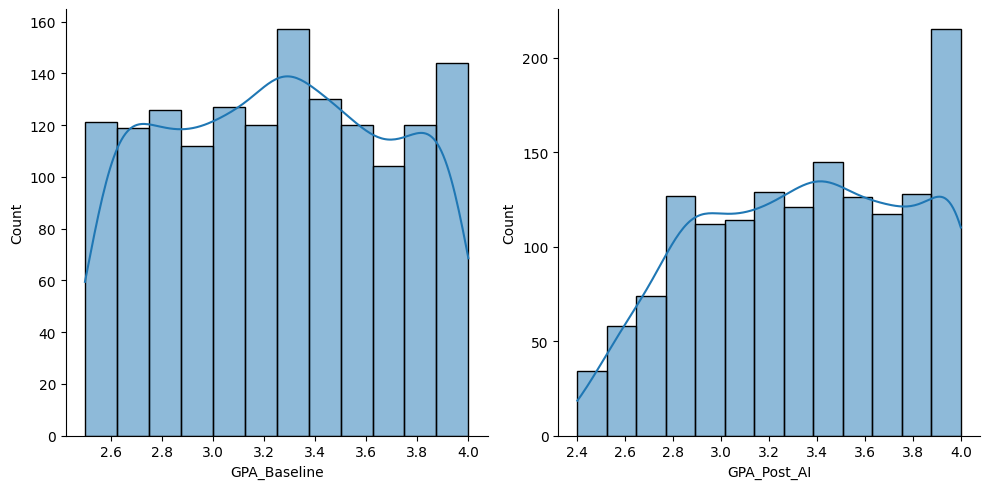

In [14]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

ax[0] = sns.histplot(data=df, x='GPA_Baseline', ax=ax[0], kde=True)
ax[1] = sns.histplot(data=df, x='GPA_Post_AI', ax=ax[1], kde=True)

sns.despine(left=False, right=True, top=True, bottom=False)
plt.tight_layout()

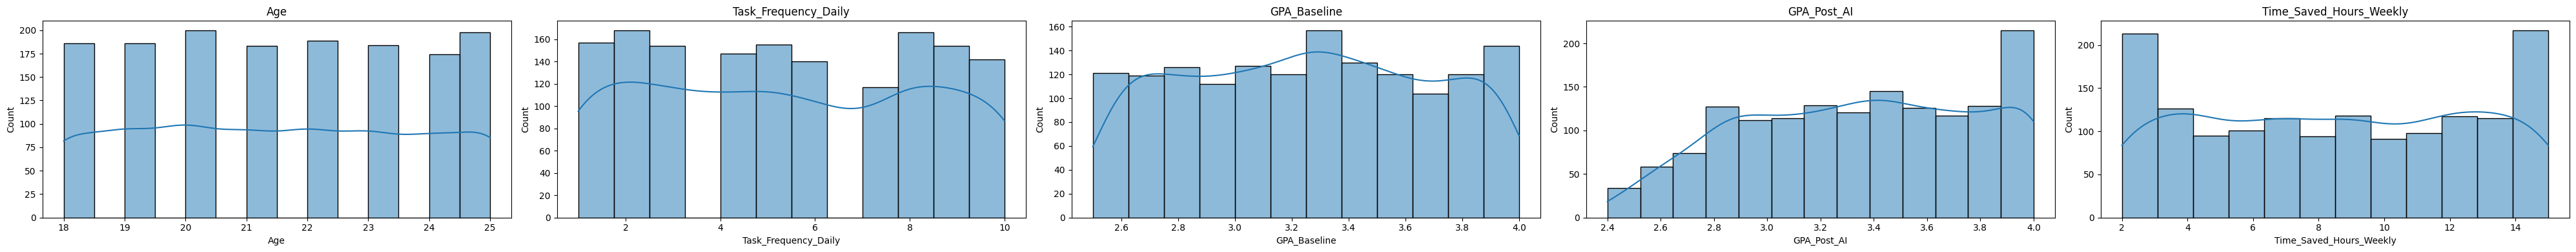

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['Age', "Task_Frequency_Daily", "GPA_Baseline", "GPA_Post_AI", "Time_Saved_Hours_Weekly", "Career_Confidence_Score"]

fig, axes = plt.subplots(1, 5, figsize=(40, 4))

for ax, col in zip(axes.flatten(), cols):
    sns.histplot(data=df, x=col, ax=ax, kde=True)
    ax.set_title(col)

plt.tight_layout()
plt.show()

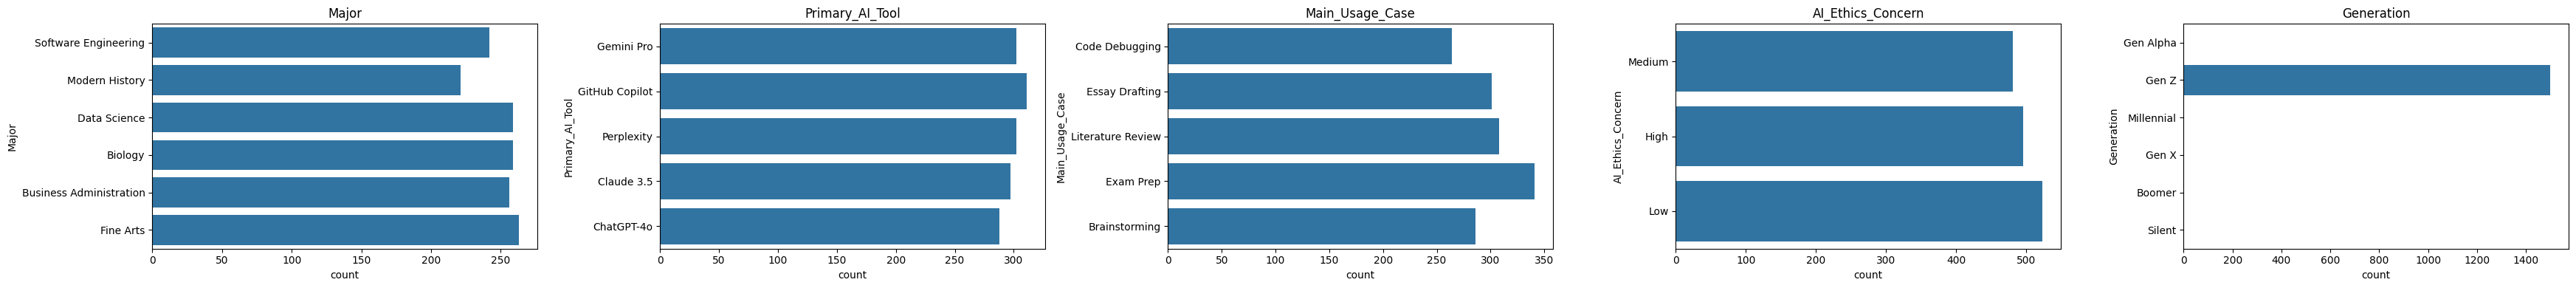

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = df.drop(['Student_ID','Age','Task_Frequency_Daily','Task_Frequency_Daily','GPA_Baseline','GPA_Post_AI','Time_Saved_Hours_Weekly','Career_Confidence_Score'], axis=1).columns.to_list()

fig, axes = plt.subplots(1, 5, figsize=(35, 4))

for ax, col in zip(axes.flatten(), cols):
    sns.countplot(data=df, y=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()